In [1]:
import pandas as pd
income = pd.read_csv('income.csv')
income.head()

,Age,Education,Salary
0,25,Bachelors,43.9
1,30,Bachelors,54.4
2,45,Bachelors,62.5
3,55,Bachelors,72.5
4,65,Bachelors,74.6


In [2]:
income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        30 non-null     int64  
 1   Education  30 non-null     object 
 2   Salary     30 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 852.0+ bytes


In [3]:
income.describe()

,Age,Salary
count,30.000000,30.000000
mean,43.366667,64.406667
std,14.375466,26.202684
min,24.000000,16.800000
25%,30.500000,46.350000
50%,45.000000,62.100000
75%,55.000000,76.800000
max,65.000000,118.000000


In [4]:
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns

<Axes: xlabel='Education', ylabel='Salary'>

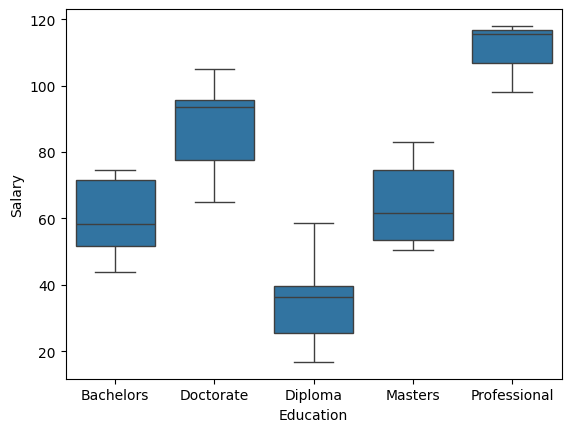

In [5]:
ax = sns.boxplot(data=income, x='Education', y='Salary')
ax

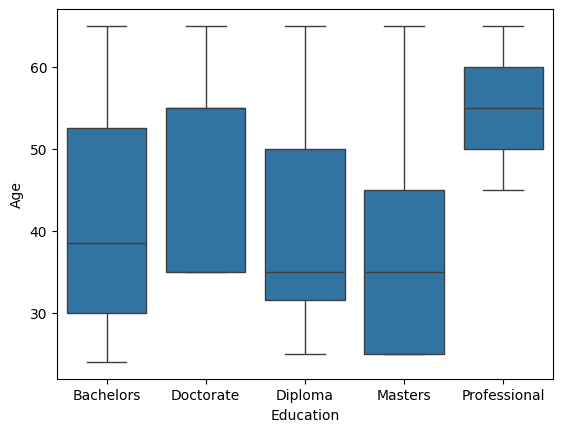

In [6]:
ax = sns.boxplot(data=income, x='Education', y='Age')

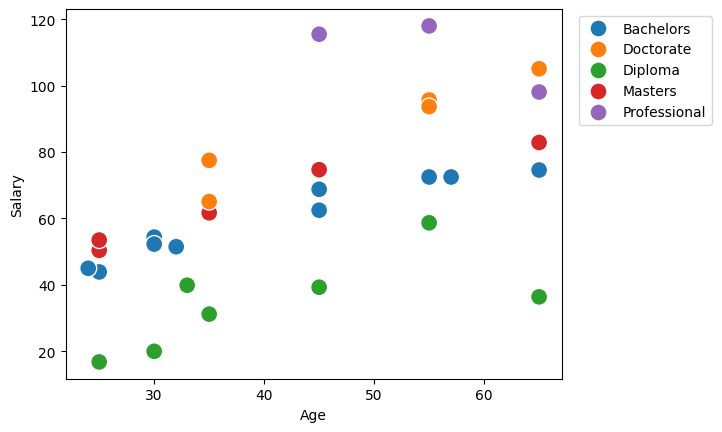

In [7]:
ax = sns.scatterplot(
    data = income,
    x='Age',
    y='Salary',
    hue = 'Education',
    s=150
)
ax = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

In [8]:
y = income[['Salary']]

In [9]:
x = income[['Age', 'Education']]

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.6, stratify = x['Education'],random_state=1234)

In [11]:
x_train.shape, x_test.shape

((18, 2), (12, 2))

In [12]:
x_train.head()

,Age,Education
0,25,Bachelors
16,45,Masters
17,65,Masters
29,65,Professional
8,25,Diploma


In [13]:
x_train = pd.get_dummies(x_train)
x_train = x_train.astype(int)
x_train.head()

,Age,Education_Bachelors,Education_Diploma,Education_Doctorate,Education_Masters,Education_Professional
0,25,1,0,0,0,0
16,45,0,0,0,1,0
17,65,0,0,0,1,0
29,65,0,0,0,0,1
8,25,0,1,0,0,0


In [14]:
x_test = pd.get_dummies(x_test)
x_test = x_test.astype(int)
x_test.head()

,Age,Education_Bachelors,Education_Diploma,Education_Doctorate,Education_Masters,Education_Professional
9,30,0,1,0,0,0
21,25,0,0,0,1,0
4,65,1,0,0,0,0
10,35,0,1,0,0,0
7,65,0,0,1,0,0


In [15]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=1234)

In [16]:
model = regressor.fit(x_train, y_train)

In [17]:
model.score(x_test, y_test)

0.5853149222529794

In [18]:
y_pred = model.predict(x_test)

In [20]:
from sklearn.metrics import mean_absolute_error
ms = mean_absolute_error(y_test, y_pred)
ms

13.541666666666666

In [23]:
#Visualizing the Regression Tree

[Text(0.48295454545454547, 0.9375, 'Age <= 34.0\nsquared_error = 544.18\nsamples = 18\nvalue = 65.367'),
 Text(0.18181818181818182, 0.8125, 'Education_Bachelors <= 0.5\nsquared_error = 176.924\nsamples = 5\nvalue = 41.3'),
 Text(0.33238636363636365, 0.875, 'True  '),
 Text(0.09090909090909091, 0.6875, 'Age <= 29.0\nsquared_error = 133.402\nsamples = 2\nvalue = 28.35'),
 Text(0.045454545454545456, 0.5625, 'squared_error = 0.0\nsamples = 1\nvalue = 16.8'),
 Text(0.13636363636363635, 0.5625, 'squared_error = -0.0\nsamples = 1\nvalue = 39.9'),
 Text(0.2727272727272727, 0.6875, 'Age <= 27.5\nsquared_error = 19.602\nsamples = 3\nvalue = 49.933'),
 Text(0.22727272727272727, 0.5625, 'squared_error = 0.0\nsamples = 1\nvalue = 43.9'),
 Text(0.3181818181818182, 0.5625, 'Age <= 31.0\nsquared_error = 2.102\nsamples = 2\nvalue = 52.95'),
 Text(0.2727272727272727, 0.4375, 'squared_error = 0.0\nsamples = 1\nvalue = 54.4'),
 Text(0.36363636363636365, 0.4375, 'squared_error = -0.0\nsamples = 1\nvalue = 

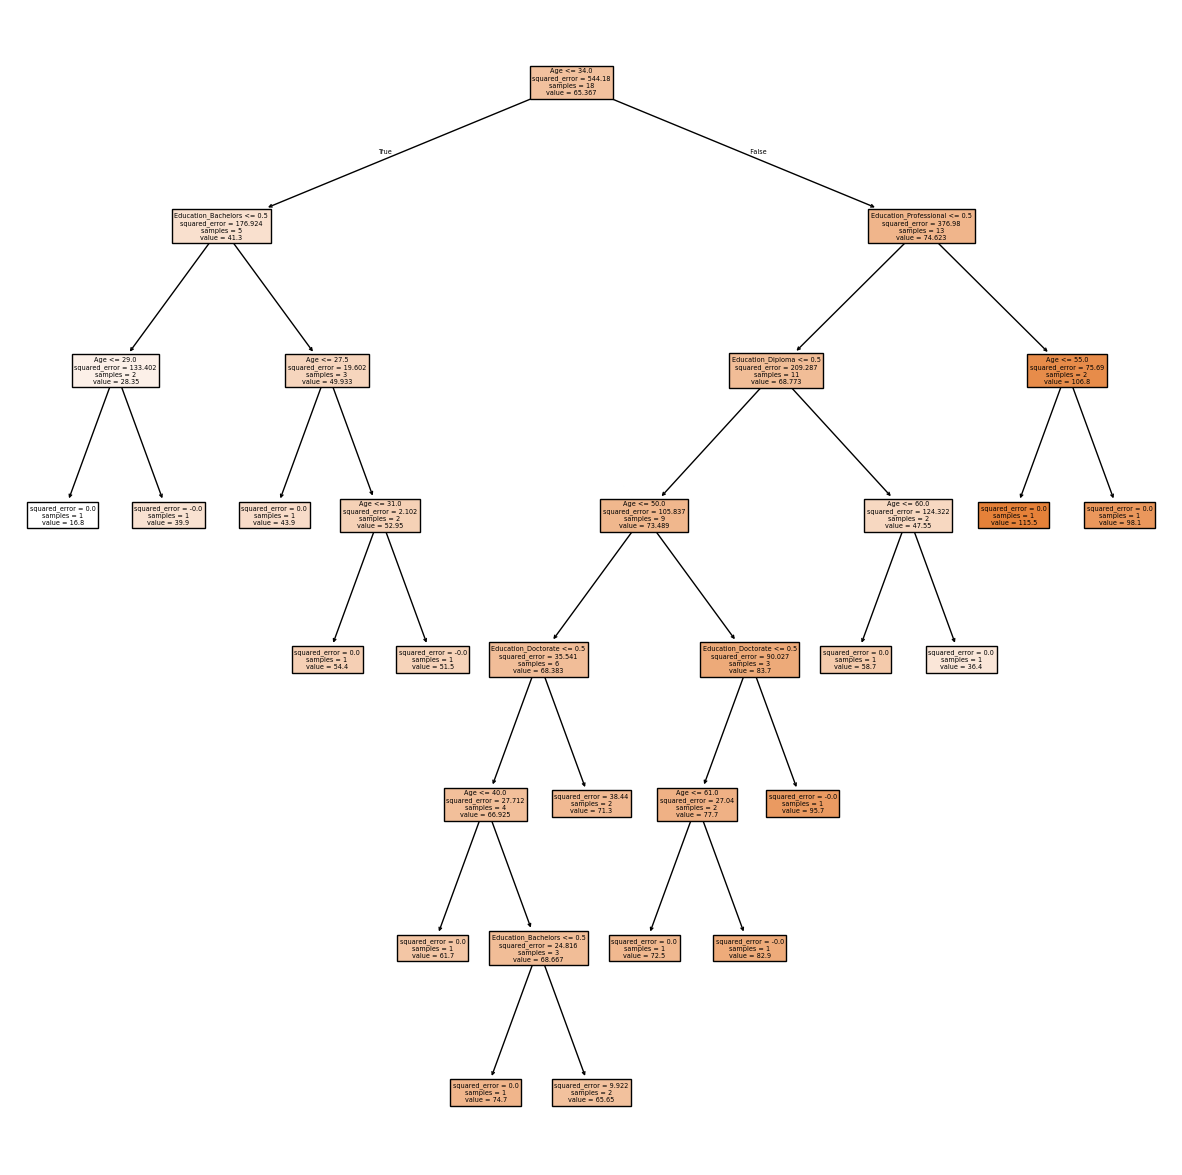

In [27]:
from sklearn import tree
plt.figure(figsize=(15, 15))
tree.plot_tree(
    model,
    feature_names = list(x_train.columns),
    filled=True
)

[Text(0.5, 0.8333333333333334, 'Age <= 34.0\nsquared_error = 544.18\nsamples = 18\nvalue = 65.367'),
 Text(0.25, 0.5, 'Education_Bachelors <= 0.5\nsquared_error = 176.924\nsamples = 5\nvalue = 41.3'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.375, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.75, 0.5, 'Education_Professional <= 0.5\nsquared_error = 376.98\nsamples = 13\nvalue = 74.623'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.875, 0.16666666666666666, '\n  (...)  \n')]

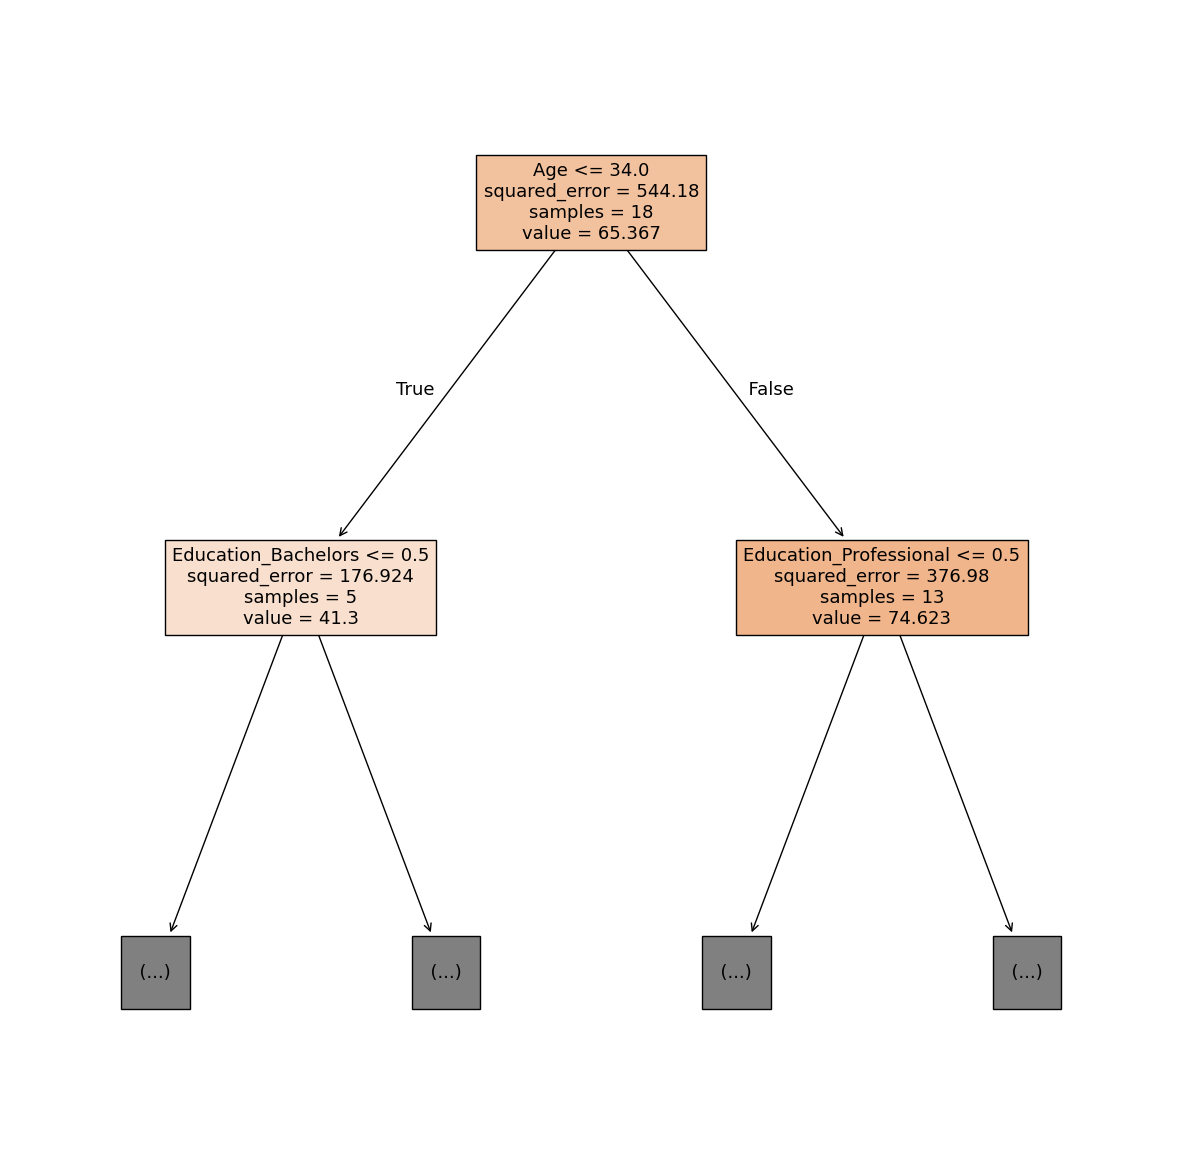

In [29]:
from sklearn import tree
plt.figure(figsize=(15,15))
tree.plot_tree(
    model,
    feature_names = x_train.columns,
    filled = True,
    max_depth =1
)

In [33]:
importance = model.feature_importances_
importance

array([0.54597998, 0.06326845, 0.11352129, 0.02490287, 0.        ,
       0.25232742])

Text(0, 0.5, 'Importance')

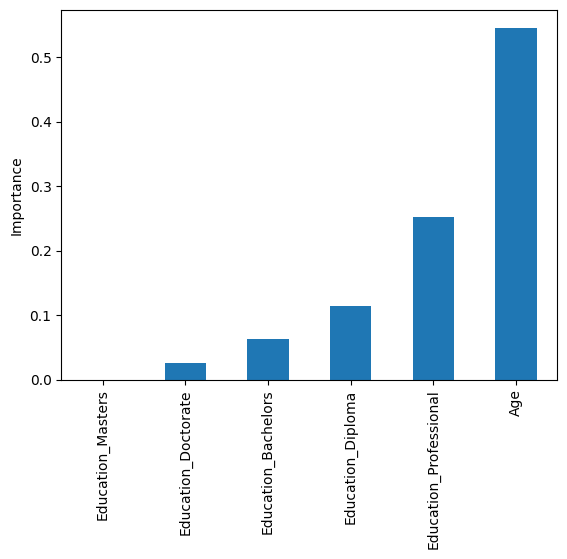

In [37]:
feature_importance = pd.Series(importance, index=x_train.columns)
feature_importance.sort_values().plot(kind='bar')
plt.ylabel('Importance')

In [38]:
#Pruning the Tree using Post Pruning Method

In [40]:
model.score(x_train, y_train)

0.9901253057607573

In [42]:
model.score(x_test, y_test)

0.5853149222529794

In [45]:
path = regressor.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = path.ccp_alphas
list(ccp_alphas)

[np.float64(0.0),
 np.float64(0.23361111111110705),
 np.float64(2.1578395061724223),
 np.float64(3.004444444444693),
 np.float64(3.0334259259259144),
 np.float64(8.409999999999753),
 np.float64(12.000000000000506),
 np.float64(13.813611111110644),
 np.float64(14.822500000000016),
 np.float64(26.06669753086468),
 np.float64(31.05601851851865),
 np.float64(61.1659960718292),
 np.float64(135.95562548562512),
 np.float64(222.77094017094078)]

In [47]:
ccp_alphas = ccp_alphas[:-1]

In [51]:
train_scores, test_scores = [], []
for alpha in ccp_alphas:
    regressor = DecisionTreeRegressor(random_state=1234, ccp_alpha=alpha)
    model_= regressor.fit(x_train, y_train)
    train_scores.append(model_.score(x_train, y_train))
    test_scores.append(model_.score(x_test, y_test))

Text(0.5, 1.0, 'R-Squared Values')

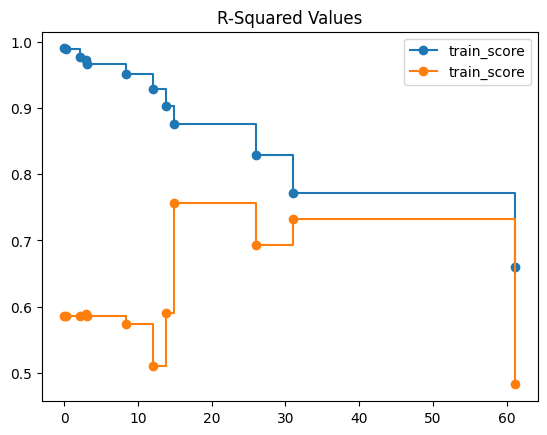

In [56]:
plt.plot(
    ccp_alphas,
    train_scores,
    marker='o',
    label='train_score',
    drawstyle='steps-post'
)
plt.plot(
    ccp_alphas,
    test_scores,
    marker='o',
    label='train_score',
    drawstyle='steps-post'
)
plt.legend()
plt.title('R-Squared Values')

In [58]:
test_scores

[0.5853149222529794,
 0.5857107382012932,
 0.5857107382012932,
 0.5889110156116097,
 0.5861012049128272,
 0.5742699063850475,
 0.5110187660049715,
 0.5901546580161237,
 0.7572572323335666,
 0.6933555316243081,
 0.7328980549684876,
 0.4823659659054369]

In [60]:
ix = test_scores.index(max(test_scores))
best_alpha = ccp_alphas[ix]
best_alpha

np.float64(14.822500000000016)

In [64]:
regressor = DecisionTreeRegressor(random_state=1234, ccp_alpha =best_alpha)
model = regressor.fit(x_train, y_train)

In [66]:
model.score(x_train, y_train)

0.8765762758237674

In [68]:
model.score(x_test, y_test)

0.7572572323335666

[Text(0.5, 0.9, 'Age <= 34.0\nsquared_error = 544.18\nsamples = 18\nvalue = 65.367'),
 Text(0.25, 0.7, 'Education_Bachelors <= 0.5\nsquared_error = 176.924\nsamples = 5\nvalue = 41.3'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'squared_error = 133.402\nsamples = 2\nvalue = 28.35'),
 Text(0.375, 0.5, 'squared_error = 19.602\nsamples = 3\nvalue = 49.933'),
 Text(0.75, 0.7, 'Education_Professional <= 0.5\nsquared_error = 376.98\nsamples = 13\nvalue = 74.623'),
 Text(0.625, 0.8, '  False'),
 Text(0.625, 0.5, 'Education_Diploma <= 0.5\nsquared_error = 209.287\nsamples = 11\nvalue = 68.773'),
 Text(0.5, 0.3, 'Age <= 50.0\nsquared_error = 105.837\nsamples = 9\nvalue = 73.489'),
 Text(0.375, 0.1, 'squared_error = 35.541\nsamples = 6\nvalue = 68.383'),
 Text(0.625, 0.1, 'squared_error = 90.027\nsamples = 3\nvalue = 83.7'),
 Text(0.75, 0.3, 'squared_error = 124.322\nsamples = 2\nvalue = 47.55'),
 Text(0.875, 0.5, 'squared_error = 75.69\nsamples = 2\nvalue = 106.8')]

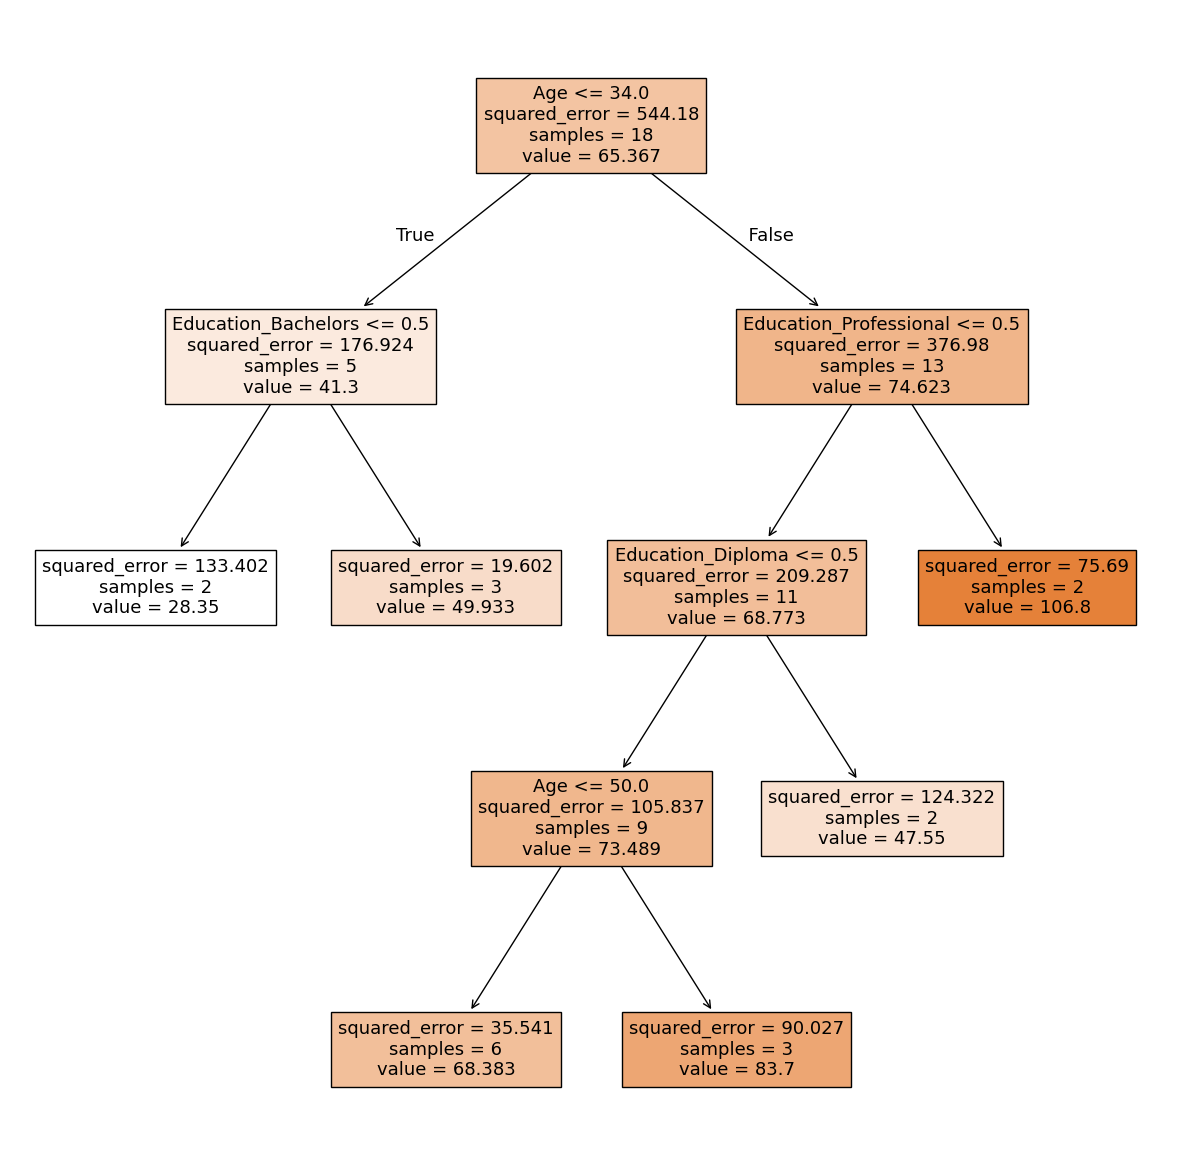

In [70]:
plt.figure(figsize=(15,15))
tree.plot_tree(
    model,
    feature_names=x_train.columns,
    filled=True
)